#NOTEBOOK ANALISE EXPLORATORIA - OBESITY

O objetivo deste notebook é realizar análise exploratória de dados de obesidade, já considerando um dataset limpo, com os dados tratados na etapa anterior.

O arquivo Obesity_Limpo.csv foi gerado após o feature engennering do arquivo original, obesity.csv

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

##Analisando se o feature engeneering dropou alguma linha do dataset original

O gráfico de distribuição de niveis de obesidade por quantidade de pessoas da amostra nos mostra que o não houve perda de dados durante a limpeza e refinamento dos dados

Text(0, 0.5, 'Categoria')

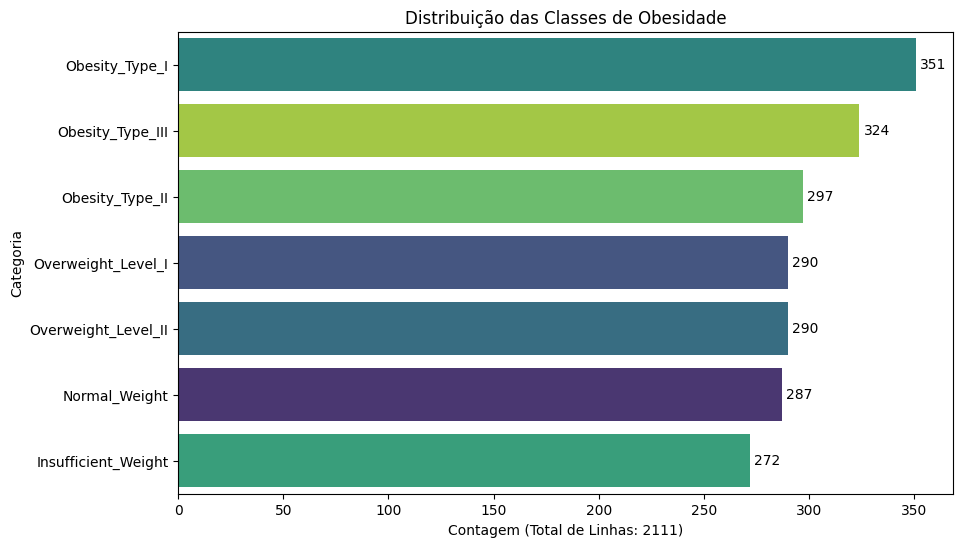

In [36]:
# Carregando os dados limpos
df_clean = pd.read_csv('https://raw.githubusercontent.com/LuciAguiar/Tech_Chalenge_Obesity/refs/heads/main/Obesity_Limpo.csv', sep=',')

total_linhas = len(df_clean)

# Criando a figura
plt.figure(figsize=(10, 6))

# Contagem das classes ordenadas
order = df_clean['Obesity'].value_counts().index
ax = sns.countplot(y=df_clean['Obesity'], order=order, palette='viridis', hue=df_clean['Obesity'], legend=False)

# Adicionando os rótulos de dados nas barras
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Configurando os títulos e rótulos
plt.title('Distribuição das Classes de Obesidade')
plt.xlabel(f'Contagem (Total de Linhas: {total_linhas})')
plt.ylabel('Categoria')

Também fizemos um gráfico de distribuição por idade, altura e peso para verificar se os dados estão coerentes

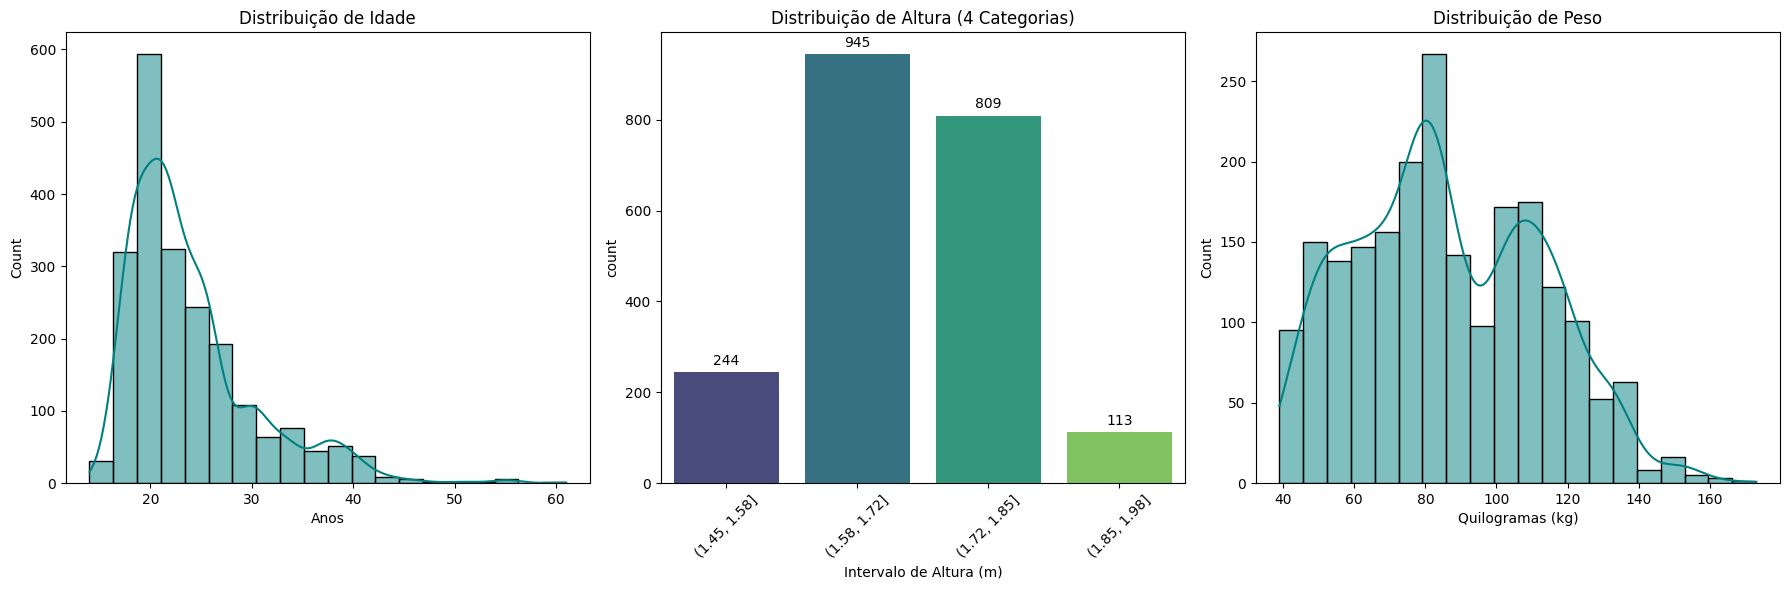

In [37]:
df_clean = pd.read_csv('https://raw.githubusercontent.com/LuciAguiar/Tech_Chalenge_Obesity/refs/heads/main/Obesity_Limpo.csv', sep=',')

# Agrupando a coluna Height em 4 categorias limitando a 2 casas decimais (precision=2)
df_clean['Height_Cat'] = pd.cut(df_clean['Height'], bins=4, precision=2)

# Criando a figura
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Idade (Age)
sns.histplot(df_clean['Age'], kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('Distribuição de Idade')
axes[0].set_xlabel('Anos')

# 2. Altura (Height) - 4 Categorias (Agora com formatação limpa)
ax_height = sns.countplot(x='Height_Cat', data=df_clean, ax=axes[1], palette='viridis', hue='Height_Cat', legend=False)
axes[1].set_title('Distribuição de Altura (4 Categorias)')
axes[1].set_xlabel('Intervalo de Altura (m)')
axes[1].tick_params(axis='x', rotation=45)
for container in ax_height.containers:
    ax_height.bar_label(container, padding=3)

# 3. Peso (Weight)
sns.histplot(df_clean['Weight'], kde=True, ax=axes[2], color='teal', bins=20)
axes[2].set_title('Distribuição de Peso')
axes[2].set_xlabel('Quilogramas (kg)')

# Ajustando layout e salvando
plt.tight_layout()

ANALISE EXPLORATÓRIA (EDA)

Iniciamos a análise explorátoria verificando a existênca de outliers através do gráfico de dispersão por categoria clinica (nivel de obesidade) x consumo calórico

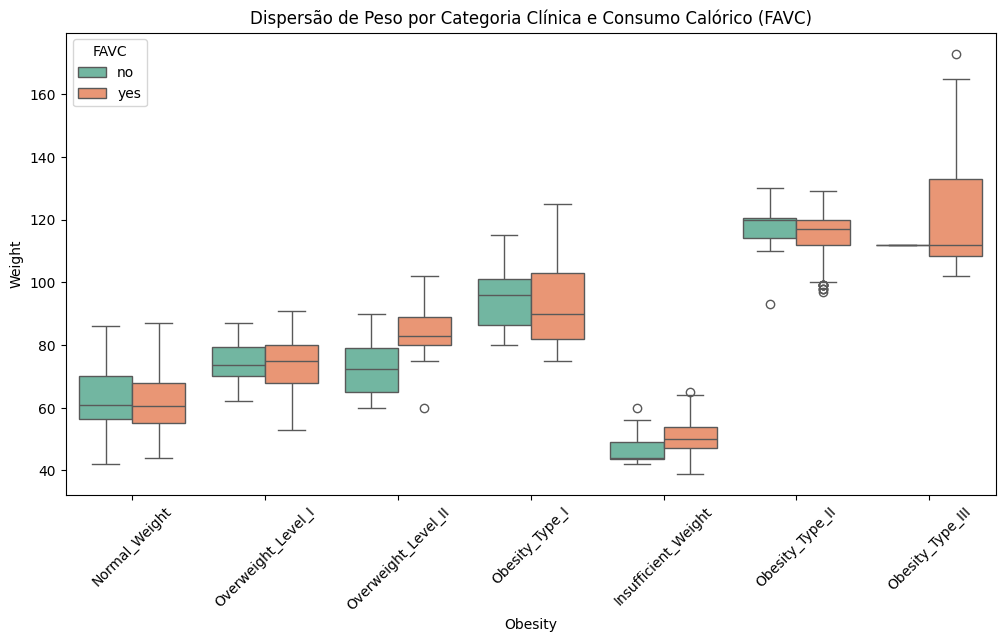

In [38]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='Obesity', y='Weight', hue='FAVC', palette='Set2')
plt.xticks(rotation=45)
plt.title('Dispersão de Peso por Categoria Clínica e Consumo Calórico (FAVC)')
plt.show()

Criamos o cálculo IMC, considerando o peso e altura para verificar se realmente o indice IMC identificado está consistente com a categoria clínica, de acordo com a OMS

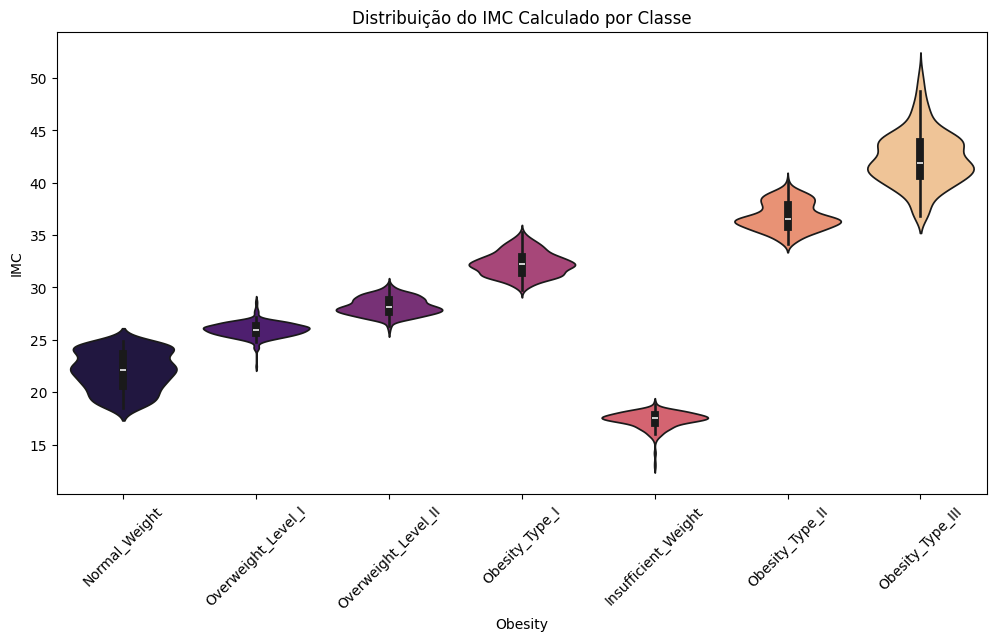

In [39]:
df_clean['IMC'] = df_clean['Weight'] / (df_clean['Height'] ** 2)

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_clean, x='Obesity', y='IMC', hue='Obesity', palette='magma', legend=False)
plt.xticks(rotation=45)
plt.title('Distribuição do IMC Calculado por Classe')
plt.show()

##ANALISE DE CORRELAÇÃO COM IMC

Criamos um heatmap para verificar a correlação entre as features do dataset

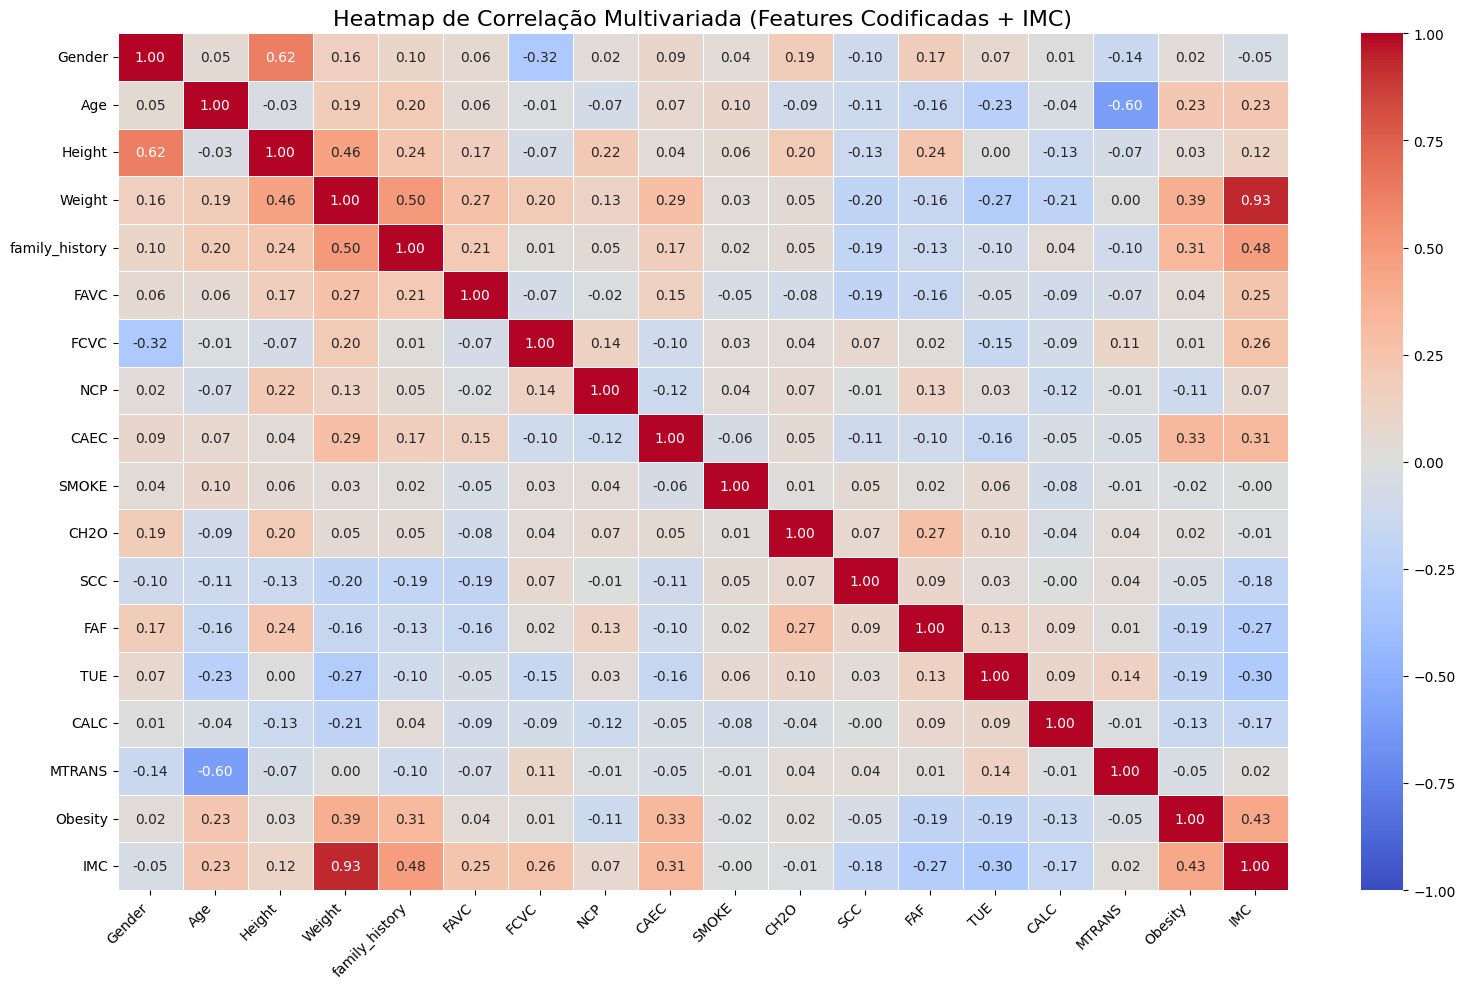

In [40]:
# Criando a feature de IMC analítico
df_clean['IMC'] = df_clean['Weight'] / (df_clean['Height'] ** 2)

# Removendo a coluna de intervalos (Height_Cat) se ela estiver na memória para evitar o TypeError
if 'Height_Cat' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Height_Cat'])

# Identificando e codificando as colunas categóricas (tipo object)
colunas_categoricas = df_clean.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in colunas_categoricas:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# Calculando a matriz de correlação (forçando apenas variáveis numéricas)
matriz_correlacao = df_clean.corr(numeric_only=True)

# Criando e plotando o Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap de Correlação Multivariada (Features Codificadas + IMC)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

##ANALISE DE CORRELAÇÃO SEM PESO E ALTURA

Este novo heatmap indica a correlação de variáveis comportamentais no indice de obesidade

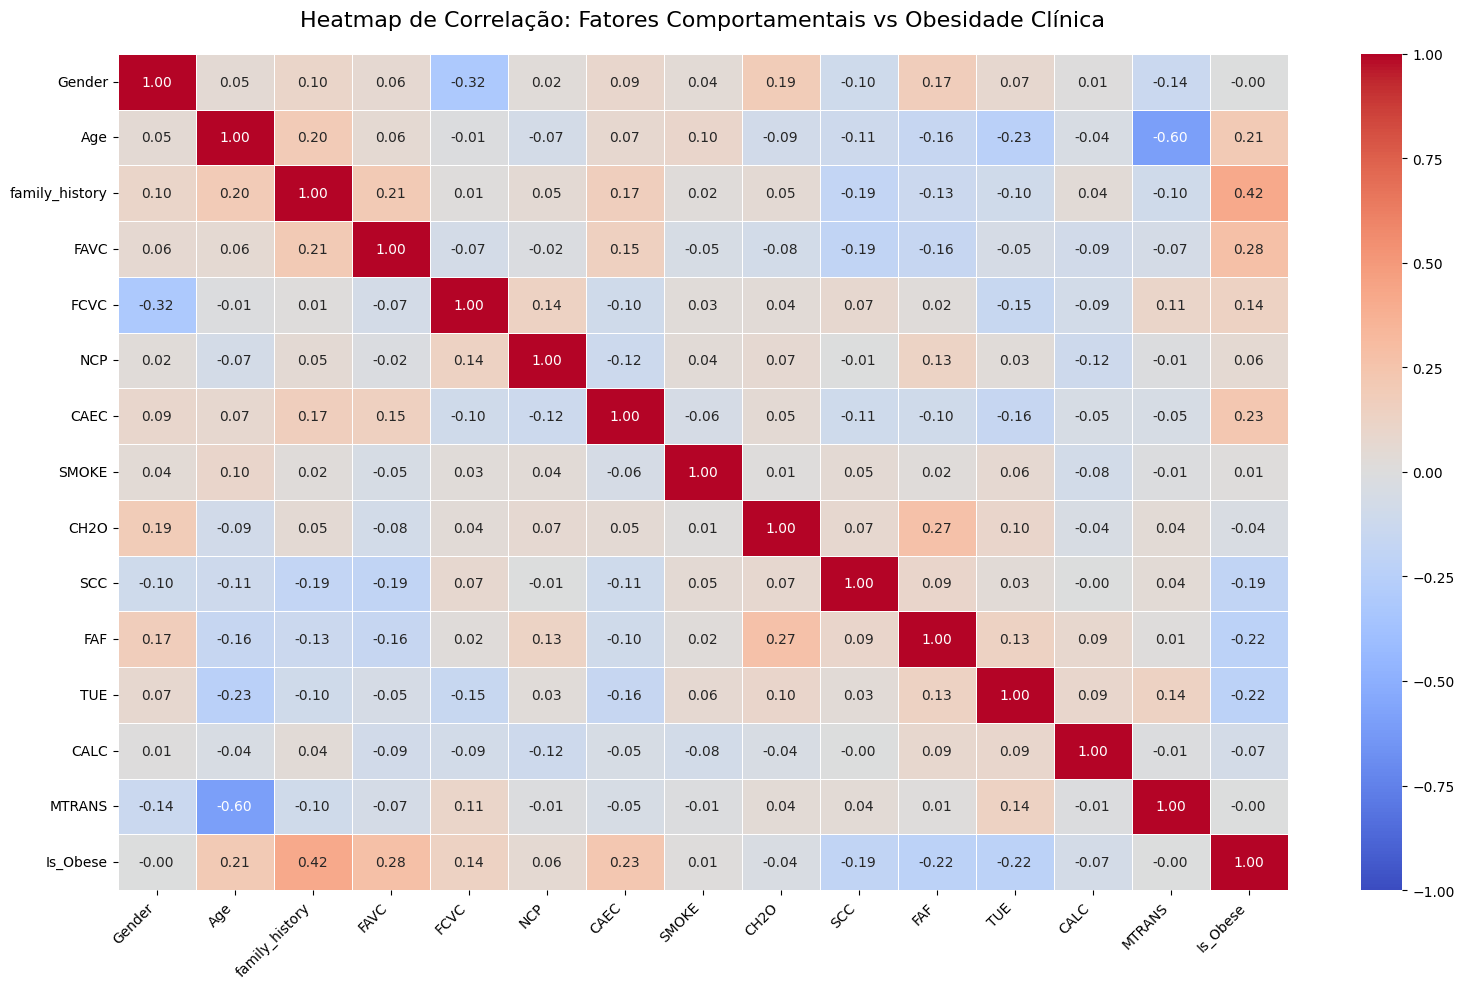

Is_Obese          1.000000
family_history    0.416607
FAVC              0.278355
CAEC              0.232819
Age               0.205189
FCVC              0.136075
NCP               0.056340
SMOKE             0.011578
Gender           -0.001436
MTRANS           -0.002263
CH2O             -0.038913
CALC             -0.073897
SCC              -0.187952
TUE              -0.221377
FAF              -0.221615
Name: Is_Obese, dtype: float64


In [41]:
# Reload df_clean
df_clean = pd.read_csv('https://raw.githubusercontent.com/LuciAguiar/Tech_Chalenge_Obesity/refs/heads/main/Obesity_Limpo.csv', sep=',')


# 1. Agrupando a variável alvo (Criando a flag de Obesidade Clínica)
classes_obesidade = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Obesity_Type_1', 'Obesity_Type_2', 'Obesity_Type_3']
df_clean['Is_Obese'] = df_clean['Obesity'].isin(classes_obesidade).astype(int)

# 2. Dropando as variáveis baseadas em medição física e a coluna original
colunas_para_dropar = ['Height', 'Weight', 'Obesity']
df_clean = df_clean.drop(columns=[col for col in colunas_para_dropar if col in df_clean.columns])

# Se a coluna de IMC (Height_Cat) estiver na memória, também dropamos
if 'Height_Cat' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Height_Cat'])
if 'IMC' in df_clean.columns:
    df_clean = df_clean.drop(columns=['IMC'])

# 3. Label Encoding para as variáveis categóricas restantes
colunas_categoricas = df_clean.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in colunas_categoricas:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 4. Matriz de Correlação
matriz_correlacao = df_clean.corr()

# 5. Plotando o Heatmap
plt.figure(figsize=(16, 10)) # Aumentei levemente o tamanho da figura para dar mais respiro
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

# Adicionei um 'pad' no título para ele não grudar no gráfico
plt.title('Heatmap de Correlação: Fatores Comportamentais vs Obesidade Clínica', fontsize=16, pad=20)

# Mantendo a rotação e garantindo o alinhamento correto
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# A MÁGICA ACONTECE AQUI: bbox_inches='tight' impede que qualquer texto seja cortado
plt.tight_layout()
plt.savefig('heatmap_comportamental.png', bbox_inches='tight', dpi=300)

# Mostra o gráfico na tela do Colab
plt.show()

# Exibindo as variáveis mais correlacionadas com 'Is_Obese'
print(matriz_correlacao['Is_Obese'].sort_values(ascending=False))

#MACHINE LEARNING

Obtendo análise preditiva com base em dados comportamentais

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

🎯 Acurácia do Modelo Pura e Comportamental: 81.56%

📋 Relatório de Classificação Detalhado:
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.93      0.90        54
      Normal_Weight       0.65      0.69      0.67        58
     Obesity_Type_I       0.72      0.73      0.72        70
    Obesity_Type_II       0.90      0.92      0.91        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.75      0.72      0.74        58
Overweight_Level_II       0.83      0.74      0.78        58

           accuracy                           0.82       423
          macro avg       0.82      0.82      0.82       423
       weighted avg       0.82      0.82      0.82       423



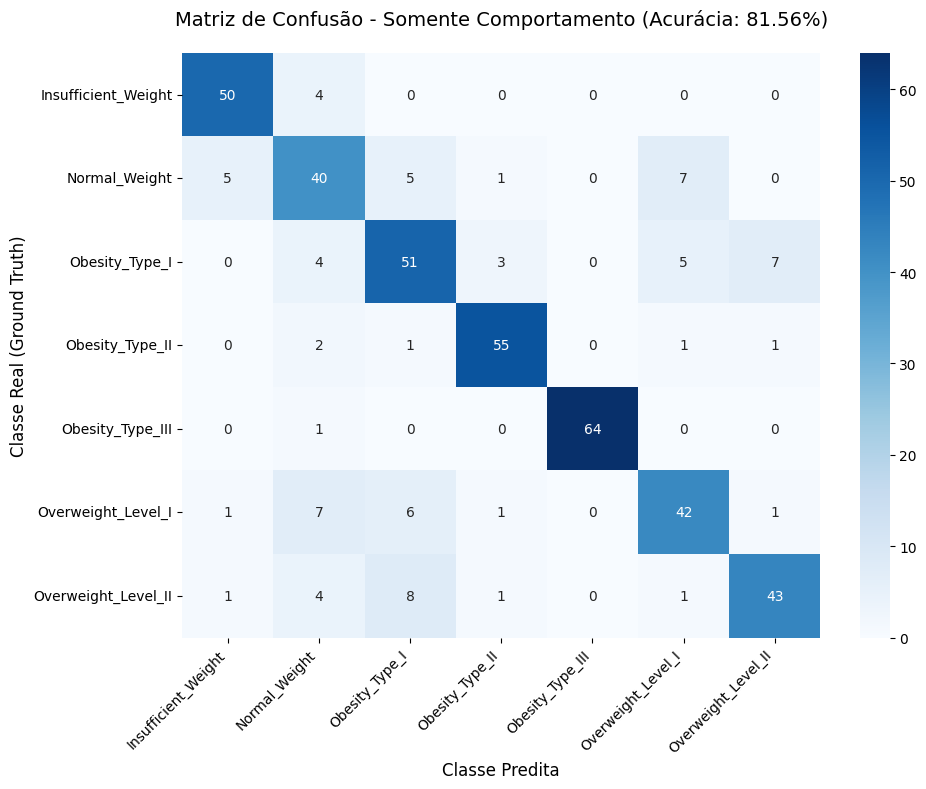

In [43]:
df_clean = pd.read_csv('https://raw.githubusercontent.com/LuciAguiar/Tech_Chalenge_Obesity/refs/heads/main/Obesity_Limpo.csv', sep=',')

# 2. Separando Variáveis (X) e Alvo (y)
# REMOVENDO totalmente as variáveis físicas para analisar APENAS o comportamento e demografia
X = df_clean.drop(columns=['Weight', 'Height', 'Obesity'])
y = df_clean['Obesity']

# 3. Pipeline de Codificação (Label Encoding)
le_dict = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# Codificando o vetor alvo (y)
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# 4. Divisão de Dados (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 5. Instanciando e Treinando o Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# 6. Predições e Métricas
y_pred = rf_model.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f"🎯 Acurácia do Modelo Pura e Comportamental: {acuracia:.2%}\n")
print("📋 Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred, target_names=le_y.classes_))

# 7. Plotagem da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_y.classes_, yticklabels=le_y.classes_)

plt.title(f'Matriz de Confusão - Somente Comportamento (Acurácia: {acuracia:.2%})', pad=20, fontsize=14)
plt.ylabel('Classe Real (Ground Truth)', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('matriz_confusao_rf_comportamental.png', bbox_inches='tight', dpi=300)
plt.show()